# CycleGAN: RGB → Synthetic NDVI (Unpaired Image Translation)

**Architecture**: CycleGAN (Zhu et al., 2017)  
**Task**: Unpaired image-to-image translation — RGB drone imagery → synthetic NDVI  
**Dataset**: RGB/NDVI rice field patches (Roboflow)  
**Framework**: pytorch-CycleGAN-and-pix2pix (junyanz)  

Unlike Pix2Pix, CycleGAN does **not** require pixel-aligned pairs. It learns two mappings simultaneously — G_A: A→B and G_B: B→A — enforced by a **cycle-consistency loss** so that G_B(G_A(x)) ≈ x. This makes it far more practical for field data where perfect pairing is unavailable.

---

| Component | Detail |
|-----------|--------|
| Generators | G_A (RGB→NDVI), G_B (NDVI→RGB) |
| Discriminators | D_A (real/fake NDVI), D_B (real/fake RGB) |
| Loss | Adversarial + Cycle-Consistency (λ=10) + Identity (λ_id=0.5) |
| Evaluation | L1, MSE, PSNR, SSIM, FID |


 # 1 · Clone Repository

In [1]:
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
%cd pytorch-CycleGAN-and-pix2pix

Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.23 MiB | 41.95 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.
/kaggle/working/pytorch-CycleGAN-and-pix2pix


# 2 · Inspect Repository Structure

In [2]:
import os

%cd /kaggle/working/pytorch-CycleGAN-and-pix2pix
print(os.listdir())

/kaggle/working/pytorch-CycleGAN-and-pix2pix
['LICENSE', 'docs', 'environment.yml', '.git', '.gitignore', 'train.py', 'models', 'test.py', 'pix2pix.ipynb', 'CycleGAN.ipynb', 'datasets', '.replit', 'options', 'data', 'util', 'scripts', 'imgs', 'README.md']


In [3]:
!ls -F

CycleGAN.ipynb	docs/		 LICENSE   pix2pix.ipynb  test.py
data/		environment.yml  models/   README.md	  train.py
datasets/	imgs/		 options/  scripts/	  util/


# 3 · Install Dependencies

Dominate (HTML page builder) & Visdom (live training monitor)
These are used by the junyanz repo for built-in visualisation.

In [4]:
!pip install dominate visdom

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for visdom: filename=visdom-0.2.4-py3-none-any.whl size=1408195 sha256=3c1da103b9d32eaf80cc13c311c5e5449a613c0d1f7c15b65572c4badcf79878
  Stored in directory: /root/.cache/pip/wheels/37/6c/38/64eeaa310e325aacda723e6df1f79ab5e9f31ba195264e04a8
Successfully built visdom


Additional scientific libraries needed for quantitative evaluation
torch-fidelity provides FID (Fréchet Inception Distance) — the standard GAN metric


In [5]:
!pip install scikit-image torch-fidelity lpips

# Verify installs
import skimage
import torch_fidelity
import lpips

print('scikit-image:', skimage.__version__)
print('lpips imported successfully')
print('torch-fidelity imported successfully')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.9 MB/s eta 0:00:00
scikit-image: 0.25.2
lpips imported successfully
torch-fidelity imported successfully


# 4 · Weights & Biases (Experiment Tracking)

- W&B is the modern, cloud-based successor to Visdom. It automatically logs losses,
- learning rate, generated images, and system metrics — accessible from any browser.
- Every run is versioned so you can compare experiments side-by-side.


In [6]:
!pip install --upgrade wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.3/27.3 MB 72.7 MB/s eta 0:00:00
  Attempting uninstall: wandb
    Found existing installation: wandb 0.25.0
    Uninstalling wandb-0.25.0:
      Successfully uninstalled wandb-0.25.0


In [7]:
import os
import wandb

# ─── Replace with your own API key ───────────────────────────
os.environ['WANDB_API_KEY'] = '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'
# ─────────────────────────────────────────────────────────────

wandb.login()

run = wandb.init(
    project='cyclegan_rgb2ndvi',
    name='cyclegan_baseline',
    config={
        'model':            'cycle_gan',
        'direction':        'AtoB',
        'n_epochs':         100,
        'n_epochs_decay':   100,
        'batch_size':       1,
        'input_size':       512,
        'preprocess':       'none',
        'lambda_A':         10.0,
        'lambda_B':         10.0,
        'lambda_identity':  0.5,
        'lr':               0.0002,
        'dataset':          'traintestrgbndvi-ilx7x',
    }
)

print(f'W&B run initialised: {run.name}  ({run.url})')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: devanadi (devanadi-politeknik-elektronika-negeri-surabaya) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.27.0
wandb: Run data is saved locally in /kaggle/working/pytorch-CycleGAN-and-pix2pix/wandb/run-20260518_125135-d2w3dwrj
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run cyclegan_baseline
wandb: ⭐️ View project at https://wandb.ai/devanadi-politeknik-elektronika-negeri-surabaya/cyclegan_rgb2ndvi
wandb: 🚀 View run at https://wandb.ai/devanadi-politeknik-elektronika-negeri-surabaya/cyclegan_rgb2ndvi/runs/d2w3dwrj


W&B run initialised: cyclegan_baseline  (https://wandb.ai/devanadi-politeknik-elektronika-negeri-surabaya/cyclegan_rgb2ndvi/runs/d2w3dwrj)


## 5 · Download Dataset (Roboflow)

**Dataset**: RGB / NDVI rice field patches  
**Source**: [Roboflow Universe — datasetta-ubg4x](https://universe.roboflow.com/datasetta-ubg4x/traintestrgbndvi-ilx7x)  

> **CycleGAN note**: unlike Pix2Pix, pairing is **not** required here.
> trainA and trainB can contain completely different images — the model
> learns the domain distribution, not pixel-to-pixel correspondences.


In [8]:
!rm -rf /kaggle/working/cyclegan-dataset

In [9]:
!pip install roboflow

import roboflow, os

# ─── Dataset configuration ───────────────────────────────────
ROBOFLOW_API_KEY = 'iCyCB9cRabBZAL2Fhj7l'   # replace
WORKSPACE        = 'datasetta-ubg4x'
PROJECT_NAME     = 'traintestrgbndvi-ilx7x'
DATASET_VERSION  = 1
DOWNLOAD_PATH    = '/kaggle/working/cyclegan-dataset'
# ─────────────────────────────────────────────────────────────

rf      = roboflow.Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT_NAME)
version = project.version(DATASET_VERSION)
dataset = version.download('folder', location=DOWNLOAD_PATH)

# Unzip if Roboflow delivered a zip
%cd /content/cyclegan-dataset
!unzip -o roboflow.zip 2>/dev/null && rm -f roboflow.zip
%cd /content

print('Dataset ready at', DOWNLOAD_PATH)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 120.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0,


Extracting Dataset Version Zip to /kaggle/working/cyclegan-dataset in folder:: 100%|██████████| 608/608 [00:00<00:00, 3782.52it/s]


[Errno 2] No such file or directory: '/content/cyclegan-dataset'
/kaggle/working/pytorch-CycleGAN-and-pix2pix
/content
Dataset ready at /kaggle/working/cyclegan-dataset


# 6 · Prepare Data for CycleGAN

## 6.1 · Train / Test Split (80 / 20)

CycleGAN expects four folders:  
`trainA` / `testA` → Domain A (RGB)  
`trainB` / `testB` → Domain B (NDVI)  

Because the translation is **unpaired**, we split each domain independently.
Matching filenames between A and B is **not** required for training,
but keeping them aligned here is still recommended for reproducible evaluation.


In [10]:
import os
from sklearn.model_selection import train_test_split
from shutil import copyfile

# ─── Paths ────────────────────────────────────────────────────
DATASET_NAME   = 'cyclegan-dataset'
DATASET_VER    = '1.0'
ROOT           = f'/kaggle/working/{DATASET_NAME}'
INPUT_FOLDER   = os.path.join(ROOT, 'train')
OUTPUT_FOLDER  = '/kaggle/working/pytorch-CycleGAN-and-pix2pix/datasets/datasetta-ubg4x'
RANDOM_STATE   = 2024
TEST_RATIO     = 0.20
# ─────────────────────────────────────────────────────────────

if not os.path.exists(INPUT_FOLDER):
    raise FileNotFoundError(f'Input folder not found: {INPUT_FOLDER}')

# Create CycleGAN output directories
for split in ['trainA', 'trainB', 'testA', 'testB']:
    os.makedirs(os.path.join(OUTPUT_FOLDER, split), exist_ok=True)

ndvi_path = os.path.join(INPUT_FOLDER, 'ndvi')
rgb_path  = os.path.join(INPUT_FOLDER, 'rgb')

for p, name in [(ndvi_path, 'ndvi'), (rgb_path, 'rgb')]:
    if not os.path.exists(p):
        raise FileNotFoundError(f'{name} subfolder not found at {p}')

# Sort so positional pairing is preserved for evaluation
rgb_files  = sorted([f for f in os.listdir(rgb_path)  if f.lower().endswith('.jpg')])
ndvi_files = sorted([f for f in os.listdir(ndvi_path) if f.lower().endswith('.jpg')])

print(f'Total RGB  images : {len(rgb_files)}')
print(f'Total NDVI images : {len(ndvi_files)}')

if len(rgb_files) != len(ndvi_files):
    print('[WARNING] RGB and NDVI counts differ — pairing will be skipped for evaluation.')

# Split RGB domain
rgb_train, rgb_test = train_test_split(rgb_files,  test_size=TEST_RATIO, random_state=RANDOM_STATE)
# Split NDVI domain independently (unpaired is fine for CycleGAN training)
ndvi_train, ndvi_test = train_test_split(ndvi_files, test_size=TEST_RATIO, random_state=RANDOM_STATE)

def copy_files(files, src, dst):
    for f in files:
        copyfile(os.path.join(src, f), os.path.join(dst, f))

copy_files(rgb_train,  rgb_path,  os.path.join(OUTPUT_FOLDER, 'trainA'))
copy_files(rgb_test,   rgb_path,  os.path.join(OUTPUT_FOLDER, 'testA'))
copy_files(ndvi_train, ndvi_path, os.path.join(OUTPUT_FOLDER, 'trainB'))
copy_files(ndvi_test,  ndvi_path, os.path.join(OUTPUT_FOLDER, 'testB'))

print(f'\nSplit complete (random_state={RANDOM_STATE}, test_ratio={TEST_RATIO})')
for folder in ['trainA', 'trainB', 'testA', 'testB']:
    path = os.path.join(OUTPUT_FOLDER, folder)
    print(f'  {folder}: {len(os.listdir(path))} images')
print(f'Saved to: {OUTPUT_FOLDER}')

Total RGB  images : 150
Total NDVI images : 150

Split complete (random_state=2024, test_ratio=0.2)
  trainA: 120 images
  trainB: 120 images
  testA: 30 images
  testB: 30 images
Saved to: /kaggle/working/pytorch-CycleGAN-and-pix2pix/datasets/datasetta-ubg4x


## 6.2 · Rename to Sequential Filenames

In [11]:
import os

BASE = '/kaggle/working/pytorch-CycleGAN-and-pix2pix/datasets/datasetta-ubg4x'

def rename_sequential(folder_path, ext='jpg'):
    """Rename all files in folder to zero-padded sequential names (001.jpg, 002.jpg, ...)."""
    files = sorted(os.listdir(folder_path))
    for idx, old_name in enumerate(files, start=1):
        new_name = f'{idx:03d}.{ext}'
        old_path = os.path.join(folder_path, old_name)
        new_path = os.path.join(folder_path, new_name)
        if old_path != new_path:
            os.rename(old_path, new_path)
    return len(files)

for split in ['trainA', 'trainB', 'testA', 'testB']:
    n = rename_sequential(os.path.join(BASE, split))
    print(f'{split}: {n} files renamed')

# Verify alignment in A and B sets
print('\nFirst 5 testA:', sorted(os.listdir(os.path.join(BASE, 'testA')))[:5])
print('First 5 testB:', sorted(os.listdir(os.path.join(BASE, 'testB')))[:5])

trainA: 120 files renamed
trainB: 120 files renamed
testA: 30 files renamed
testB: 30 files renamed

First 5 testA: ['001.jpg', '002.jpg', '003.jpg', '004.jpg', '005.jpg']
First 5 testB: ['001.jpg', '002.jpg', '003.jpg', '004.jpg', '005.jpg']


## 6.3 · Pre-resize All Images 512 x 512
---
Images come from the drone at **640×640**. We resize them to **512×512** here,
once, before training begins. This lets us pass `--preprocess none` to the
trainer so the loader uses images exactly as-is — no random crop, no additional
resize, no information loss at training time.

> **Why 512 and not 256?** Keeping 512×512 preserves more spatial detail in the
> NDVI signal, which matters for downstream damage area estimation. The trade-off
> is ~4× the GPU memory vs 256 — acceptable on a T4 with `batch_size=1`.


In [12]:
from PIL import Image
import os

BASE       = '/kaggle/working/pytorch-CycleGAN-and-pix2pix/datasets/datasetta-ubg4x'
TARGET_SIZE = (512, 512)
SPLITS     = ['trainA', 'trainB', 'testA', 'testB']

for split in SPLITS:
    folder  = os.path.join(BASE, split)
    files   = sorted(os.listdir(folder))
    resized = 0
    skipped = 0

    for fname in files:
        fpath = os.path.join(folder, fname)
        with Image.open(fpath) as img:
            if img.size == TARGET_SIZE:
                skipped += 1
                continue
            img_resized = img.resize(TARGET_SIZE, Image.LANCZOS)
            img_resized.save(fpath, quality=95)  # overwrite in-place
            resized += 1

    print(f'{split:<8}  {resized:>3} resized  |  {skipped:>3} already {TARGET_SIZE[0]}px  '
          f'|  total: {len(files)}')

# Spot-check: confirm final sizes
print('\nSpot-check (first file per split):')
for split in SPLITS:
    folder = os.path.join(BASE, split)
    sample = sorted(os.listdir(folder))[0]
    with Image.open(os.path.join(folder, sample)) as img:
        print(f'  {split}/{sample}  →  {img.size}')


trainA    120 resized  |    0 already 512px  |  total: 120
trainB    120 resized  |    0 already 512px  |  total: 120
testA      30 resized  |    0 already 512px  |  total: 30
testB      30 resized  |    0 already 512px  |  total: 30

Spot-check (first file per split):
  trainA/001.jpg  →  (512, 512)
  trainB/001.jpg  →  (512, 512)
  testA/001.jpg  →  (512, 512)
  testB/001.jpg  →  (512, 512)


# 7 · Visual Verification of Input Domains

- Before training, visually confirm that trainA (RGB) and trainB (NDVI) contain
-  the correct domain images. A mislabelled domain causes the model to learn the
- inverse mapping, which is silent and catastrophic.


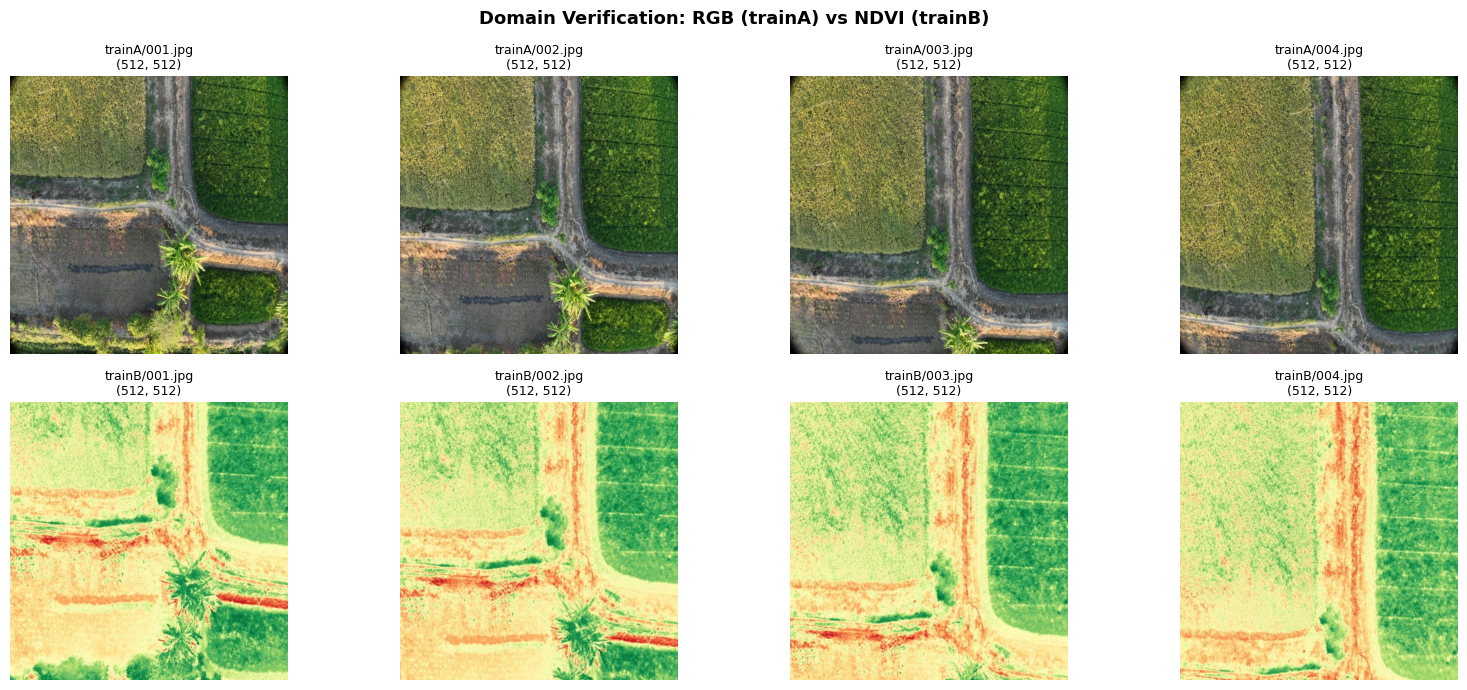

Saved domain_verification.png


In [13]:
import os
from PIL import Image
import matplotlib.pyplot as plt

BASE      = '/kaggle/working/pytorch-CycleGAN-and-pix2pix/datasets/datasetta-ubg4x'
N_SAMPLES = 4

fig, axes = plt.subplots(2, N_SAMPLES, figsize=(16, 7))
fig.suptitle('Domain Verification: RGB (trainA) vs NDVI (trainB)', fontsize=13, fontweight='bold')

for col, fname in enumerate(sorted(os.listdir(os.path.join(BASE, 'trainA')))[:N_SAMPLES]):
    for row, domain in enumerate(['trainA', 'trainB']):
        domain_files = sorted(os.listdir(os.path.join(BASE, domain)))
        img_path = os.path.join(BASE, domain, domain_files[col])
        img = Image.open(img_path)
        axes[row, col].imshow(img)
        axes[row, col].set_title(f'{domain}/{domain_files[col]}\n{img.size}', fontsize=9)
        axes[row, col].axis('off')

axes[0, 0].set_ylabel('Domain A (RGB)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Domain B (NDVI)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/domain_verification.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved domain_verification.png')

# 8 · Prep Train

## Verify Checkpoint

In [14]:
import os

BASE = '/kaggle/input/datasets/devanadi/cyclegan-rice-ndvi-checkpoints'
print(f'Contents of {BASE}:\n')
for f in sorted(os.listdir(BASE)):
    full = os.path.join(BASE, f)
    if os.path.isfile(full):
        size_mb = os.path.getsize(full) / (1024**2)
        print(f'  {f:<45}  {size_mb:.1f} MB')
    else:
        print(f'  {f}/')
        for sub in sorted(os.listdir(full)):
            size_mb = os.path.getsize(os.path.join(full, sub)) / (1024**2)
            print(f'    {sub:<43}  {size_mb:.1f} MB')

Contents of /kaggle/input/datasets/devanadi/cyclegan-rice-ndvi-checkpoints:

  10_net_D_A.pth                                 10.6 MB
  10_net_D_B.pth                                 10.6 MB
  10_net_G_A.pth                                 43.4 MB
  10_net_G_B.pth                                 43.4 MB
  15_net_D_A.pth                                 10.6 MB
  15_net_D_B.pth                                 10.6 MB
  15_net_G_A.pth                                 43.4 MB
  15_net_G_B.pth                                 43.4 MB
  20_net_D_A.pth                                 10.6 MB
  20_net_D_B.pth                                 10.6 MB
  20_net_G_A.pth                                 43.4 MB
  20_net_G_B.pth                                 43.4 MB
  25_net_D_A.pth                                 10.6 MB
  25_net_D_B.pth                                 10.6 MB
  25_net_G_A.pth                                 43.4 MB
  25_net_G_B.pth                                 43.4 MB
  30_net_D_

## Verify Path

In [15]:
import os

# Search for the .pth files to find the real path
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.pth'):
            print(os.path.join(root, f))
            break
    if any(f.endswith('.pth') for f in files):
        break

/kaggle/input/datasets/devanadi/cyclegan-rice-ndvi-checkpoints/5_net_D_B.pth


## Restore Checkpoint

In [16]:
import os, shutil

SRC = '/kaggle/input/datasets/devanadi/cyclegan-rice-ndvi-checkpoints'
DST = '/kaggle/working/pytorch-CycleGAN-and-pix2pix/checkpoints/rgb2ndvi_cyclegan'
os.makedirs(DST, exist_ok=True)

for f in os.listdir(SRC):
    src_path = os.path.join(SRC, f)
    dst_path = os.path.join(DST, f)
    if os.path.isfile(src_path):
        shutil.copy(src_path, dst_path)

print('Restored:')
for f in sorted(os.listdir(DST)):
    size_mb = os.path.getsize(os.path.join(DST, f)) / (1024**2)
    print(f'  {f:<45}  {size_mb:.1f} MB')

Restored:
  10_net_D_A.pth                                 10.6 MB
  10_net_D_B.pth                                 10.6 MB
  10_net_G_A.pth                                 43.4 MB
  10_net_G_B.pth                                 43.4 MB
  15_net_D_A.pth                                 10.6 MB
  15_net_D_B.pth                                 10.6 MB
  15_net_G_A.pth                                 43.4 MB
  15_net_G_B.pth                                 43.4 MB
  20_net_D_A.pth                                 10.6 MB
  20_net_D_B.pth                                 10.6 MB
  20_net_G_A.pth                                 43.4 MB
  20_net_G_B.pth                                 43.4 MB
  25_net_D_A.pth                                 10.6 MB
  25_net_D_B.pth                                 10.6 MB
  25_net_G_A.pth                                 43.4 MB
  25_net_G_B.pth                                 43.4 MB
  30_net_D_A.pth                                 10.6 MB
  30_net_D_B.pth     

## Confirm GPU

In [17]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


# 9 · Train

In [18]:
%cd /kaggle/working/pytorch-CycleGAN-and-pix2pix

!python train.py \
    --dataroot ./datasets/datasetta-ubg4x \
    --name rgb2ndvi_cyclegan \
    --model cycle_gan \
    --direction AtoB \
    --n_epochs 100 \
    --n_epochs_decay 100 \
    --batch_size 1 \
    --load_size 512 \
    --crop_size 512 \
    --preprocess resize \
    --no_flip \
    --lr 0.0002 \
    --lambda_A 10.0 \
    --lambda_B 10.0 \
    --lambda_identity 0.5 \
    --save_epoch_freq 5 \
    --save_latest_freq 500 \
    --print_freq 30 \
    --display_freq 100 \
    --continue_train \
    --epoch_count 32 \
    2>&1 | tee training_log_cyclegan.txt

/kaggle/working/pytorch-CycleGAN-and-pix2pix
----------------- Options ---------------
               batch_size: 1                             
                    beta1: 0.5                           
          checkpoints_dir: ./checkpoints                 
           continue_train: True                          	[default: False]
                crop_size: 512                           	[default: 256]
                 dataroot: ./datasets/datasetta-ubg4x    	[default: None]
             dataset_mode: unaligned                     
                direction: AtoB                          
             display_freq: 100                           	[default: 400]
          display_winsize: 256                           
                    epoch: latest                        
              epoch_count: 32                            	[default: 1]
                 gan_mode: lsgan                         
                init_gain: 0.02                          
                init_type

## Safe in Epoch 50

In [19]:
import shutil, os
from datetime import datetime

CHECKPOINT_DIR = '/kaggle/working/pytorch-CycleGAN-and-pix2pix/checkpoints/rgb2ndvi_cyclegan'
timestamp      = datetime.now().strftime('%Y%m%d_%H%M%S')
zip_out        = f'/kaggle/working/rgb2ndvi_cyclegan_epoch50_{timestamp}'

shutil.make_archive(zip_out, 'zip', CHECKPOINT_DIR)
size_mb = os.path.getsize(zip_out + '.zip') / (1024**2)
print(f'Saved : {zip_out}.zip  ({size_mb:.1f} MB)')

Saved : /kaggle/working/rgb2ndvi_cyclegan_epoch50_20260518_235208.zip  (4870.7 MB)
